# MOVIE SCREENCAPS !!!

woohoo! lets play with some movies! but as images!

## set up

In [1]:
# Some possible helper files from class

!wget -q https://github.com/PSAM-5020-2026S-A/5020-utils/raw/main/src/audio_utils.py
!wget -q https://github.com/PSAM-5020-2026S-A/5020-utils/raw/main/src/data_utils.py
!wget -q https://github.com/PSAM-5020-2026S-A/5020-utils/raw/main/src/image_utils.py
!wget -q https://github.com/PSAM-5020-2026S-A/5020-utils/raw/main/src/text_utils.py

In [2]:
# Some possible libraries.
# This isn't complete.

import matplotlib.pyplot as plt
import pandas as pd
import PIL.Image as PImage

from os import listdir, path

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.manifold import TSNE
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.svm import SVC

from data_utils import object_from_json_url, classification_error, display_confusion_matrix
from image_utils import get_pixels, make_image
from text_utils import get_top_words



In [ ]:
from pathlib import Path
import re
import requests
import json
from PIL import Image
from IPython.display import display
import os

## data cleanup

accessing resize_images (where all the data is)

In [4]:
#load image data

base_path = Path("../resized_frames")

print(base_path)
print(base_path.exists())

print(Path.cwd())


../resized_frames
True
/Users/hwangw/Projects/ml_finalproject/msdvml_finalproject


In [5]:
for d in base_path.iterdir():
    print(d.name)
    for f in d.iterdir():
        print(f.name)
        break
    break

Meet Joe Black (1998)
frame_0955.jpg


In [6]:
rows = []

for d in base_path.iterdir():
    if not d.is_dir():
        continue

    folder_name = d.name

    # extract movie + year
    match = re.match(r"(.+)\((\d{4})\)", folder_name)
    if match:
        movie_name = match.group(1).strip()
        year = int(match.group(2))
    else:
        movie_name = folder_name
        year = None

    for img_path in d.iterdir():
        if img_path.suffix.lower() not in [".jpg", ".png"]:
            continue

        # extract frame number
        frame_match = re.search(r"frame_(\d+)", img_path.name)
        frame_num = int(frame_match.group(1)) if frame_match else None

        rows.append({
            "filepath": str(img_path),
            "movie": movie_name,
            "year": year,
            "frame": frame_num
        })

df = pd.DataFrame(rows)

In [7]:
df = df.sort_values(by=["movie", "frame"], ascending=[True, True])
df.head(20)

,filepath,movie,year,frame
641970,../resized_frames/10 Things I Hate About You (...,10 Things I Hate About You,1999.0,0
642010,../resized_frames/10 Things I Hate About You (...,10 Things I Hate About You,1999.0,1
642071,../resized_frames/10 Things I Hate About You (...,10 Things I Hate About You,1999.0,2
642027,../resized_frames/10 Things I Hate About You (...,10 Things I Hate About You,1999.0,3
642186,../resized_frames/10 Things I Hate About You (...,10 Things I Hate About You,1999.0,4
642140,../resized_frames/10 Things I Hate About You (...,10 Things I Hate About You,1999.0,5
642079,../resized_frames/10 Things I Hate About You (...,10 Things I Hate About You,1999.0,6
642129,../resized_frames/10 Things I Hate About You (...,10 Things I Hate About You,1999.0,7
642755,../resized_frames/10 Things I Hate About You (...,10 Things I Hate About You,1999.0,8
642698,../resized_frames/10 Things I Hate About You (...,10 Things I Hate About You,1999.0,9


In [8]:
sorted(df["movie"].unique())

['10 Things I Hate About You',
 '12 Monkeys',
 '12 Years a Slave',
 '127 Hours',
 '13 Hours The Secret Soldiers Of Benghazi',
 '1917',
 '21 Grams',
 '25th Hour',
 '300',
 '310 to Yuma',
 '500 Days Of Summer',
 'A Beautiful Mind',
 'A Bronx Tale',
 'A Bugs Life',
 'A Few Good Men',
 'A Fish Called Wanda',
 'A Good Person',
 'A History of Violence',
 'A League of Their Own',
 'A Man Called Otto',
 'A Scanner Darkly',
 'A Serious Man',
 'A Single Man',
 'A Star Is Born',
 'A Time To Kill',
 'A Walk to Remember',
 'About Schmidt',
 'About Time',
 'About a Boy',
 'Across the Universe',
 'Adaptation',
 'Air',
 'Aladdin',
 'Aliens Special Edition',
 'Allied',
 'Almost Famous EXTENDED',
 'American Beauty',
 'American Gangster',
 'American History X',
 'American Hustle',
 'American Sniper',
 'An Education',
 'Anastasia',
 'Anchorman The Legend Of Ron Burgundy',
 'Apocalypto',
 'Apollo 13',
 'Argo',
 'Army of Darkness',
 'As Good as It Gets',
 'Atonement',
 'August Rush',
 'Austin Powers - Inter

In [9]:
df.shape
#rows #columns

(803907, 4)

beefing through api now tmdb

In [10]:
movies = df[["movie", "year"]].drop_duplicates()
movies.head()

,movie,year
641970,10 Things I Hate About You,1999.0
359963,12 Monkeys,1995.0
235985,12 Years a Slave,2013.0
167025,127 Hours,2010.0
377966,13 Hours The Secret Soldiers Of Benghazi,2016.0


In [11]:
from keys import API_KEY

In [12]:
BASE = "https://api.themoviedb.org/3"

r = requests.get(
    f"{BASE}/configuration",
    params={"api_key": API_KEY}
)
print(r.status_code)

200


In [13]:
def get_tmdb_id(title, year):
    r = requests.get(
        "https://api.themoviedb.org/3/search/movie",
        params={
            "api_key": API_KEY,
            "query": title,
            "year": year
        }
    ).json()

    return r["results"][0]["id"] if r["results"] else None

In [14]:
def get_movie_info(movie_id):
    r = requests.get(
        f"https://api.themoviedb.org/3/movie/{movie_id}",
        params={"api_key": API_KEY}
    ).json()

    return {
        "tmdb_id": movie_id,
        "summary": r.get("overview"),
        "genres": [g["name"] for g in r.get("genres", [])],
        "original_language": r.get("original_language"),
        "production_countries": [c["name"] for c in r.get("production_countries", [])]
    }

In [15]:
def get_keywords(movie_id):
    r = requests.get(
        f"https://api.themoviedb.org/3/movie/{movie_id}/keywords",
        params={"api_key": API_KEY}
    ).json()

    return [k["name"] for k in r.get("keywords", [])]

In [16]:
def get_imdb_id(movie_id):
    r = requests.get(
        f"https://api.themoviedb.org/3/movie/{movie_id}/external_ids",
        params={"api_key": API_KEY}
    ).json()

    return r.get("imdb_id")

In [17]:
def build_movie_features(title, year):
    mid = get_tmdb_id(title, year)
    if not mid:
        return None

    info = get_movie_info(mid)
    keywords = get_keywords(mid)
    imdb_id = get_imdb_id(mid)

    info["keywords"] = keywords
    info["imdb_id"] = imdb_id

    return info

In [18]:
def get_full_movie(movie_id):
    info = get_movie_info(movie_id)
    info["keywords"] = get_keywords(movie_id)
    info["imdb_id"] = get_imdb_id(movie_id)
    return info

In [19]:
movies = df[["movie", "year"]].drop_duplicates()

lookup = {}

for _, row in movies.iterrows():
    mid = get_tmdb_id(row["movie"], row["year"])
    
    if mid:
        lookup[(row["movie"], row["year"])] = get_full_movie(mid)
    else:
        lookup[(row["movie"], row["year"])] = None

df["tmdb"] = df.apply(lambda r: lookup.get((r["movie"], r["year"])), axis=1)

In [20]:
df["genres"] = df["tmdb"].apply(lambda x: x["genres"] if x else None)
df["summary"] = df["tmdb"].apply(lambda x: x["summary"] if x else None)
df["keywords"] = df["tmdb"].apply(lambda x: x["keywords"] if x else None)
df["imdb_id"] = df["tmdb"].apply(lambda x: x["imdb_id"] if x else None)
df["language"] = df["tmdb"].apply(lambda x: x["original_language"] if x else None)
df["countries"] = df["tmdb"].apply(lambda x: x["production_countries"] if x else None)

In [21]:
#drop to clean up

df = df.drop(columns=["tmdb"])

In [22]:
df.head()

,filepath,movie,year,frame,genres,summary,keywords,imdb_id,language,countries
641970,../resized_frames/10 Things I Hate About You (...,10 Things I Hate About You,1999.0,0,"[Comedy, Romance, Drama]","On the first day at his new school, Cameron in...","[high school, seattle, washington, deception, ...",tt0147800,en,[United States of America]
642010,../resized_frames/10 Things I Hate About You (...,10 Things I Hate About You,1999.0,1,"[Comedy, Romance, Drama]","On the first day at his new school, Cameron in...","[high school, seattle, washington, deception, ...",tt0147800,en,[United States of America]
642071,../resized_frames/10 Things I Hate About You (...,10 Things I Hate About You,1999.0,2,"[Comedy, Romance, Drama]","On the first day at his new school, Cameron in...","[high school, seattle, washington, deception, ...",tt0147800,en,[United States of America]
642027,../resized_frames/10 Things I Hate About You (...,10 Things I Hate About You,1999.0,3,"[Comedy, Romance, Drama]","On the first day at his new school, Cameron in...","[high school, seattle, washington, deception, ...",tt0147800,en,[United States of America]
642186,../resized_frames/10 Things I Hate About You (...,10 Things I Hate About You,1999.0,4,"[Comedy, Romance, Drama]","On the first day at his new school, Cameron in...","[high school, seattle, washington, deception, ...",tt0147800,en,[United States of America]


## image analysis stuff

maybe final...

In [23]:
# function for one movie

def get_movie_files(df, movie_name, sort=True):
    subset = df[df["movie"] == movie_name]
    
    if sort:
        subset = subset.sort_values("frame")
    
    return subset["filepath"].tolist()

In [24]:
# filtering

def is_low_info(pxs):
    r_mean = sum(p[0] for p in pxs) / len(pxs)
    g_mean = sum(p[1] for p in pxs) / len(pxs)
    b_mean = sum(p[2] for p in pxs) / len(pxs)

    return (r_mean < 30 and g_mean < 30 and b_mean < 30) or \
           (r_mean > 225 and g_mean > 225 and b_mean > 225)

In [25]:
# batching to hopefully help... 

BATCH_SIZE = 100

movie_results = []


In [65]:
# load image faster bc no loading image

for movie in df["movie"].unique():
    files = get_movie_files(df, movie)

    print(movie, len(files))

    for path in files:
        movie_results.append({
            "movie_idx": len(movie_results),
            "movie_name": movie,
            "filepath": path
        })

10 Things I Hate About You 1000
12 Monkeys 1000
12 Years a Slave 1000
127 Hours 1000
13 Hours The Secret Soldiers Of Benghazi 1000
1917 1000
21 Grams 1000
25th Hour 1000
300 1001
310 to Yuma 1000
500 Days Of Summer 1000
A Beautiful Mind 1000
A Bronx Tale 1000
A Bugs Life 1000
A Few Good Men 1000
A Fish Called Wanda 1000
A Good Person 1000
A History of Violence 1000
A League of Their Own 1000
A Man Called Otto 1000
A Scanner Darkly 1000
A Serious Man 1000
A Single Man 1000
A Star Is Born 1000
A Time To Kill 1000
A Walk to Remember 1000
About Schmidt 1000
About Time 1000
About a Boy 1000
Across the Universe 1000
Adaptation 1000
Air 1000
Aladdin 1001
Aliens Special Edition 1000
Allied 1000
Almost Famous EXTENDED 1001
American Beauty 1001
American Gangster 1000
American History X 1000
American Hustle 1000
American Sniper 1000
An Education 1000
Anastasia 1000
Anchorman The Legend Of Ron Burgundy 1000
Apocalypto 1000
Apollo 13 1000
Argo 1001
Army of Darkness 1000
As Good as It Gets 1000
Aton

In [66]:
#dataset verification

len(movie_results)

804007

In [67]:
#batch tester 

#movie_results = movie_results[950:1050]

import random

sample_size = 150

movie_results = random.sample(movie_results, sample_size)

len(movie_results)


150

In [68]:
# frame kmeans

filtered_movie_results = []

for start in range(0, len(movie_results), BATCH_SIZE):
    batch = movie_results[start:start + BATCH_SIZE]

    for r in batch:
        img = Image.open(r["filepath"]).convert("RGB")
        img = img.resize((180, 100))

        pxs = list(img.getdata())

        valid = not is_low_info(pxs)

        if not valid:
            continue

        df_pixels = pd.DataFrame(pxs, columns=["R", "G", "B"])

        kmeans = KMeans(n_clusters=8, random_state=0, n_init="auto") 
        labels = kmeans.fit_predict(df_pixels)

        palette = kmeans.cluster_centers_.astype(int)

        # new filtered set
        filtered_movie_results.append({
            "movie_name": r.get("movie_name"),
            "frame_idx": r.get("frame_idx"),
            "filepath": r["filepath"],
            "valid_frame": True,
            "frame_reconstruction": [tuple(palette[l]) for l in labels],
            "frame_palette": palette
        })


In [69]:
# rebuild frames

for r in filtered_movie_results:
    if "frame_reconstruction" not in r:
        continue

    img = Image.new("RGB", (180, 100))
    img.putdata(r["frame_reconstruction"])
    r["frame_rebuilt_img"] = img

In [70]:
# frame swatch

for r in filtered_movie_results:
    if "frame_rebuilt_img" not in r:
        continue

    img = r["frame_rebuilt_img"].convert("RGB")
    pxs = list(img.getdata())

    df_pixels = pd.DataFrame(pxs[::3], columns=["R", "G", "B"])

    kmeans = KMeans(n_clusters=12, random_state=0)
    labels = kmeans.fit_predict(df_pixels)

    palette = kmeans.cluster_centers_.astype(int)

    counts = pd.Series(labels).value_counts()
    colors = [palette[c] for c in counts.index[:8]] # edit for counts in frame

    row = Image.new("RGB", (50 * len(colors), 50))

    for j, c in enumerate(colors):
        block = Image.new("RGB", (50, 50), tuple(c))
        row.paste(block, (j * 50, 0))

    r["frame_swatch"] = row

/Users/hwangw/.pyenv/versions/3.11.8/lib/python3.11/site-packages/sklearn/base.py:1336: ConvergenceWarning: Number of distinct clusters (8) found smaller than n_clusters (12). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/Users/hwangw/.pyenv/versions/3.11.8/lib/python3.11/site-packages/sklearn/base.py:1336: ConvergenceWarning: Number of distinct clusters (8) found smaller than n_clusters (12). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/Users/hwangw/.pyenv/versions/3.11.8/lib/python3.11/site-packages/sklearn/base.py:1336: ConvergenceWarning: Number of distinct clusters (8) found smaller than n_clusters (12). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/Users/hwangw/.pyenv/versions/3.11.8/lib/python3.11/site-packages/sklearn/base.py:1336: ConvergenceWarning: Number of distinct clusters (8) found smaller than n_clusters (12). Possibly due to duplicate points in

In [71]:
# global swatch

movie_groups = {}

for r in filtered_movie_results:
    if r.get("valid_frame") and "frame_palette" in r:
        movie_groups.setdefault(r["movie_name"], []).append(r["frame_palette"])

movie_global_palettes = {}

for movie, palettes in movie_groups.items():
    all_colors = []

    for p in palettes:
        all_colors.extend(p[:8])  # top 8

    df_all = pd.DataFrame(all_colors, columns=["R", "G", "B"])

    kmeans_global = KMeans(n_clusters=8, random_state=0, n_init="auto")
    kmeans_global.fit(df_all)

    movie_global_palettes[movie] = kmeans_global.cluster_centers_.astype(int)

movie_swatches = {}

for movie, palette in movie_global_palettes.items():
    swatch = Image.new("RGB", (50 * len(palette), 50))

    for i, c in enumerate(palette):
        swatch.paste(
            Image.new("RGB", (50, 50), tuple(c)),
            (i * 50, 0)
        )

    movie_swatches[movie] = swatch

for r in filtered_movie_results:
    r["global_swatch"] = movie_swatches.get(r["movie_name"])

In [72]:
# final with cleaned up 

final_movie_data = []

for i, r in enumerate(filtered_movie_results):
    entry = {
        "frame_idx": i,
        "movie_name": r.get("movie_name"),
        "filepath": r.get("filepath"),
    }

    if "frame_rebuilt_img" in r:
        entry["rebuild"] = r["frame_rebuilt_img"]

    if "frame_swatch" in r:
        entry["swatch"] = r["frame_swatch"]

    if "global_swatch" in r:
        entry["global_swatch"] = r["global_swatch"]

    final_movie_data.append(entry)

    

In [73]:
#tester

len(final_movie_data)

125

Frame: 90
Movie: Finding Neverland
File: ../resized_frames/Finding Neverland (2004)/frame_0245.jpg


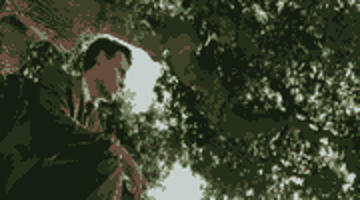

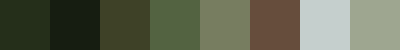

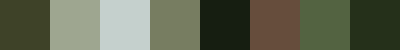

----------------------------------------


In [ ]:
idx = 90

SCALE = 2

item = final_movie_data[90]

print("Frame:", item["frame_idx"])
print("Movie:", item["movie_name"])
print("File:", item["filepath"])

if "rebuild" in item:
    img = item["rebuild"]
    display(img.resize((img.width * SCALE, img.height * SCALE)))

if "swatch" in item:
    display(item["swatch"])

if "global_swatch" in item:
    display(item["global_swatch"])

#print("-" * 40)

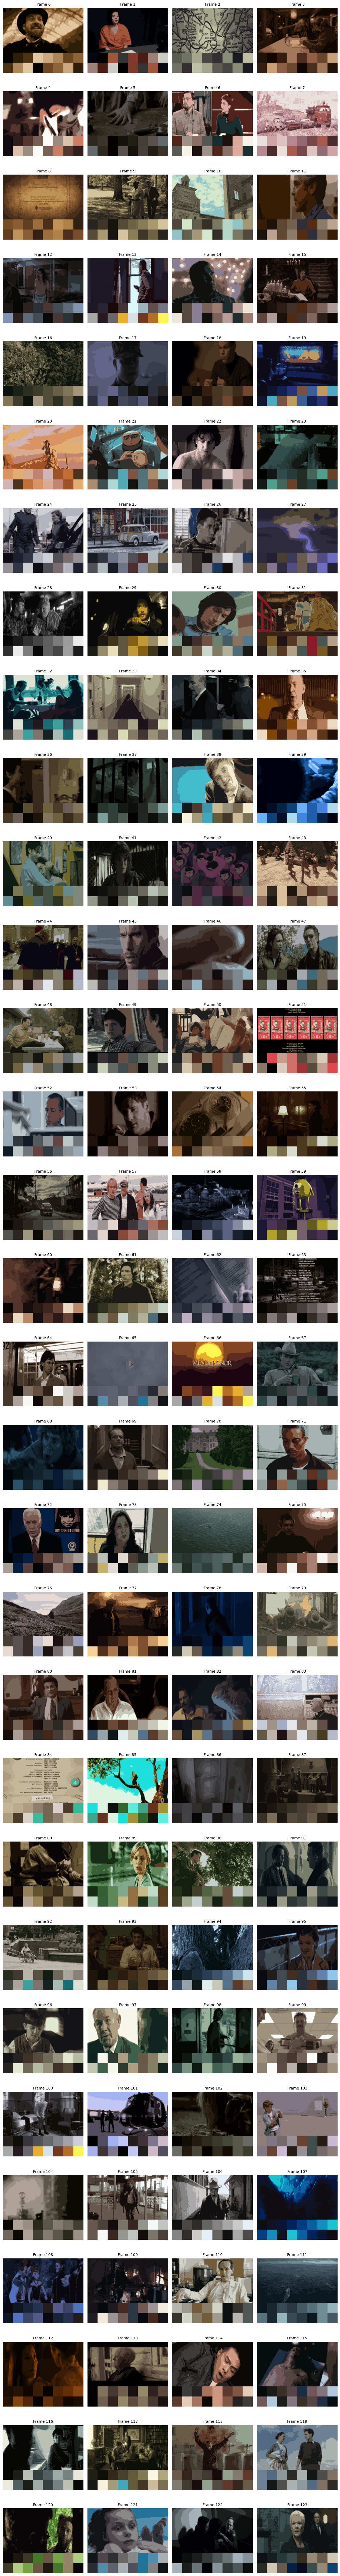

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import math

start_idx = 0
num_frames = 124
subset = final_movie_data[start_idx:start_idx + num_frames]

cols = 4
rows = math.ceil(num_frames / cols)

TARGET_WIDTH = 400

fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))  # 👈 tighter height
axes = axes.flatten()

for i, item in enumerate(subset):
    ax = axes[i]
    ax.axis("off")

    imgs = []

    for key in ["rebuild", "swatch", "global_swatch"]:
        if key in item:
            img = item[key]

            w, h = img.size
            scale = TARGET_WIDTH / w
            img = img.resize((TARGET_WIDTH, int(h * scale)))

            imgs.append(np.array(img))

    if imgs:
        stacked = np.vstack(imgs)
        ax.imshow(stacked)

    ax.set_title(f"Frame {item['frame_idx']}", fontsize=10)

for j in range(len(subset), len(axes)):
    axes[j].axis("off")

plt.subplots_adjust(
    wspace=0.05,
    hspace=0.1
)

plt.show()